# Symbolic Verification of GW Projection Coefficients

This notebook verifies the analytic derivation of the gravitational wave source integration coefficients ($c_1$ through $c_5$). 

It uses **SymPy** to:
1. Construct the exact projection tensor $\Lambda_{ij,lm}$.
2. Apply the analytic integration rules for $\hat{k}$ vectors.
3. Use geometric probing to solve for the scalar coefficients without ambiguity.

In [ ]:
import sympy as sp
from sympy import symbols, expand, simplify, Rational

# Initialize printing for pretty math output
sp.init_printing()

## 1. Define Symbols and Tensors

Here we define the fundamental physical objects:
* The wavevector $\hat{k}$ and separation vector $\hat{r}$.
* The Bessel functions $j_n(x)$ treated as atomic symbols.
* The Transverse Projector $P_{ij}$ and the Lambda Projector $\Lambda_{ij,lm}$.

In [ ]:
# Symbols
x = symbols('x', real=True) # kr
j0, j1, j2, j3, j4 = symbols('j0 j1 j2 j3 j4', real=True)
k = symbols('k0:3') # k vector components
r = symbols('r0:3') # r vector components (for integration rules)

# Kronecker Delta
def delta(a, b):
    return 1 if a == b else 0

# The Projector P_ij = delta_ij - k_i k_j
def P(i, j):
    return delta(i, j) - k[i] * k[j]

# The GW Projector Lambda (Eq. 8)
# Note: explicit Rational(1,2) ensures exact fraction arithmetic
def Lambda(i, j, l, m):
    return expand(P(i, m)*P(j, l) - Rational(1, 2)*P(i, j)*P(l, m))

## 2. Define Integration Rules

These functions act as a lookup table, replacing monomials of $\hat{k}$ with their analytic integrals derived from Bessel functions.

* **Rank 2:** $\langle k_a k_b \rangle$
* **Rank 4:** $\langle k_a k_b k_c k_d \rangle$

In [3]:
# Rank 2 Integral <k_a k_b>
def I2(a, b):
    # Formula: 4pi * ( (j1/x)*delta - j2*r_a*r_b )
    term1 = (j1/x) * delta(a,b)
    term2 = -j2 * r[a] * r[b]
    return 4 * sp.pi * (term1 + term2)

# Rank 4 Integral <k_a k_b k_c k_d>
def I4(a, b, c, d):
    # Symmetric Delta term
    S_delta = (delta(a,b)*delta(c,d) + delta(a,c)*delta(b,d) + delta(a,d)*delta(b,c))
    
    # Symmetric Delta-R-R term
    S_drr = (delta(a,b)*r[c]*r[d] + delta(a,c)*r[b]*r[d] + 
             delta(a,d)*r[b]*r[c] + delta(b,c)*r[a]*r[d] + 
             delta(b,d)*r[a]*r[c] + delta(c,d)*r[a]*r[b])
    
    # Quartic R term
    R4 = r[a]*r[b]*r[c]*r[d]
    
    return 4 * sp.pi * ((j2 / x**2)*S_delta - (j3 / x)*S_drr + j4*R4)

## 3. Build the Integrated Tensor

We now iterate through all 81 components of $\Lambda_{ij,lm}$, expand them into polynomials of $k$, and apply the integration rules to generate the fully integrated tensor $D_{ij,lm}$.

In [4]:
# Helper to integrate a single polynomial in k
def integrate_poly(poly):
    result = 0
    
    # 1. Create a map from symbol to index: {k0: 0, k1: 1, k2: 2}
    # 'k' must be the global list of symbols [k0, k1, k2] defined earlier
    k_map = {sym: i for i, sym in enumerate(k)}
    
    # 2. Create the Poly object
    # We explicitly pass 'k' to force SymPy to consider all 3 variables,
    # but the logic below is safe even if 'k' is omitted or inferred.
    p = sp.Poly(poly, k)
    
    for powers, coeff in p.terms():
        indices = []
        
        # 3. Robustly map powers back to global indices
        # p.gens contains the list of variables for these powers (e.g., (k0, k1, k2))
        for generator, power in zip(p.gens, powers):
            if power == 0:
                continue
                
            # Retrieve the true index (0, 1, or 2) from our map
            true_idx = k_map[generator]
            indices.extend([true_idx] * power)
        
        degree = len(indices)
        
        if degree == 0:
            result += coeff * (4 * sp.pi * j0)
        elif degree == 2:
            result += coeff * I2(indices[0], indices[1])
        elif degree == 4:
            result += coeff * I4(indices[0], indices[1], indices[2], indices[3])
        else:
            raise ValueError(f"Unexpected degree {degree} in expansion: {indices}")
            
    return result

print("Integrating Tensor D (this may take a few seconds)...")
D = {}

# Compute all 81 components
for i in range(3):
    for j in range(3):
        for l in range(3):
            for m in range(3):
                poly_k = Lambda(i, j, l, m)
                D[(i,j,l,m)] = integrate_poly(poly_k)
print("Done.")

Integrating Tensor D (this may take a few seconds)...
Done.


In [5]:
D

⎧                                               ⎛              2         ⎞     ↪
⎪                           ⎛j₁        2⎞       ⎜3⋅j₂   6⋅j₃⋅r₀         4⎟     ↪
⎨(0, 0, 0, 0): 2⋅π⋅j₀ - 4⋅π⋅⎜── - j₂⋅r₀ ⎟ + 2⋅π⋅⎜──── - ──────── + j₄⋅r₀ ⎟, (0 ↪
⎪                           ⎝x          ⎠       ⎜  2       x             ⎟     ↪
⎩                                               ⎝ x                      ⎠     ↪

↪                                                                              ↪
↪                                ⎛  3⋅j₃⋅r₀⋅r₁        3   ⎞                    ↪
↪ , 0, 0, 1): 2⋅π⋅j₂⋅r₀⋅r₁ + 2⋅π⋅⎜- ────────── + j₄⋅r₀ ⋅r₁⎟, (0, 0, 0, 2): 2⋅π ↪
↪                                ⎝      x                 ⎠                    ↪
↪                                                                              ↪

↪                                                                              ↪
↪                 ⎛  3⋅j₃⋅r₀⋅r₂        3   ⎞                                   ↪
↪ ⋅j₂⋅r₀⋅r₂ + 2⋅π⋅⎜- ─────

## 4. Solve for Coefficients (Probing Method)

We determine the coefficients $c_1 \dots c_5$ by evaluating the tensor contraction $\Pi = D_{ij,lm} u_i u_j v_l v_m$ at specific geometric configurations.

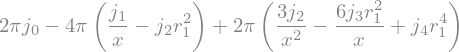

In [6]:
D[(1, 1, 1, 1)]

In [7]:
# Helper to contract D with u, v and substitute r
def contract(u_vec, v_vec, r_vec_val):
    val = 0
    # Substitution dict for r
    r_map = {r[idx]: r_vec_val[idx] for idx in range(3)}
    
    for i in range(3):
        for j in range(3):
            for l in range(3):
                for m in range(3):
                    # Substitute r values into the tensor component
                    comp = D[(i,j,l,m)].subs(r_map)
                    # Contract
                    val += comp * u_vec[i] * u_vec[j] * v_vec[l] * v_vec[m]
    return simplify(val)

print("Solving for coefficients...")

# CASE 1: S=0, C1=0, C2=0 -> c1
# u=x, v=y, r=z
val1 = contract([1,0,0], [0,1,0], [0,0,1])
c1 = val1

# CASE 2: S=1, C1=0, C2=0 -> c1 + c2
# u=x, v=x, r=z
val2 = contract([1,0,0], [1,0,0], [0,0,1])
c2 = val2 - c1

# CASE 3: S=0, C1=1, C2=0 -> c1 + c4
# u=x, v=y, r=x
val3 = contract([1,0,0], [0,1,0], [1,0,0])
c4 = val3 - c1

# CASE 4: S=0, C1=1/sqrt(2), C2=1/sqrt(2) -> c1 + c4 + 0.25*c5
# u=x, v=y, r=(x+y)/sqrt(2)
sq2 = 1/sp.sqrt(2)
val4 = contract([1,0,0], [0,1,0], [sq2, sq2, 0])
c5 = 4 * (val4 - c1 - c4)

# CASE 5: S=1, C1=1, C2=1 -> Sum of all
# u=x, v=x, r=x
val5 = contract([1,0,0], [1,0,0], [1,0,0])
c3 = val5 - (c1 + c2 + 2*c4 + c5)

print("Done.")

Solving for coefficients...
Done.


## 5. Verified Results

In [8]:
print("=== FINAL VERIFIED COEFFICIENTS ===")
print(f"c1 = {simplify(c1)}")
print(f"c2 = {simplify(c2)}")
print(f"c3 = {simplify(c3)}")
print(f"c4 = {simplify(c4)}")
print(f"c5 = {simplify(c5)}")

=== FINAL VERIFIED COEFFICIENTS ===
c1 = 2*pi*(-j0*x**2 + 2*j1*x + j2)/x**2
c2 = 4*pi*(j0*x**2 - 2*j1*x + j2)/x**2
c3 = 8*pi*(j2*x - j3)/x
c4 = 2*pi*(-j2*x - j3)/x
c5 = 2*pi*j4
